# Uber Fleet Relocation Optimization Engine

Project Overview

The goal of this project is to solve the **Fleet Relocation Problem**: Given a driver's current location and time, where is the optimal taxi zone to relocate to in order to maximize their shift earnings?

Instead of relying on a single algorithm, this notebook builds a robust **Multi-Tier Machine Learning Ensemble**:
1. **Tier 1 (Supervised Learning - Random Forest):** Predicts the immediate short-term pay rate for every zone.
2. **Tier 2 (Reinforcement Learning - Q-Learning):** Optimizes for long-term sequential earnings over an entire shift, avoiding "dead-end" zones.
3. **Tier 3 (Contextual Bandits - UCB):** Introduces controlled exploration to discover new hotspots and prevent the entire fleet from crowding a single zone.

Finally, we package these models into a deployable backend artifact using `joblib`.

## 1. Setup and Data Ingestion
We are using the NYC TLC High Volume For-Hire Vehicle (HVFHV) dataset. Because these files contain tens of millions of rows per month, training advanced RL algorithms locally would cause memory issues.

**Strategic Decision:** We will load the data, filter it specifically for standard Uber rides (excluding specialized WAV rides to avoid skewed pay rates), and take a **0.1% Stratified Sample**. Stratified sampling ensures we maintain the exact proportional distribution of rides across different hours and days of the week, preserving the true demand curve of the city.

In [1]:
import pyarrow.parquet as pq
import pandas as pd

# Load January data
trips_jan = pq.read_table('content/fhvhv_tripdata_2026-01 (1).parquet').to_pandas()

# Load February data
trips_feb = pq.read_table('content/fhvhv_tripdata_2026-02.parquet').to_pandas()

# Display the first few rows of each DataFrame
print("January Data:")
display(trips_jan.head())

print("\nFebruary Data:")
display(trips_feb.head())

January Data:


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-01 00:50:37,2026-01-01 00:52:31,2026-01-01 00:54:30,2026-01-01 01:13:23,262,79,4.300,...,2.75,0.0,0.00,21.10,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2026-01-01 00:09:12,2026-01-01 00:12:17,2026-01-01 00:12:39,2026-01-01 00:22:42,195,52,1.890,...,0.00,0.0,0.00,9.10,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2026-01-01 00:16:16,2026-01-01 00:29:33,2026-01-01 00:31:34,2026-01-01 00:55:21,25,181,1.840,...,0.00,0.0,2.67,21.94,N,N,N,N,N,0.0
3,HV0005,B03406,None,2026-01-01 00:08:19,2026-01-01 00:09:08,2026-01-01 00:09:37,2026-01-01 00:22:12,141,226,3.307,...,2.75,0.0,0.00,13.42,N,N,N,N,Y,1.5
4,HV0005,B03406,None,2026-01-01 00:21:16,2026-01-01 00:26:30,2026-01-01 00:26:40,2026-01-01 00:39:06,226,226,2.060,...,0.00,0.0,2.98,11.39,N,N,N,N,Y,0.0



February Data:


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-31 23:58:32,2026-02-01 00:03:17,2026-02-01 00:05:17,2026-02-01 00:16:12,100,161,0.95,...,2.75,0.0,0.0,11.31,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2026-02-01 00:14:36,2026-02-01 00:21:33,2026-02-01 00:22:06,2026-02-01 00:40:01,161,146,4.00,...,2.75,0.0,0.0,18.79,N,N,N,N,N,1.5
2,HV0003,B03404,B03404,2026-02-01 00:34:39,2026-02-01 00:45:05,2026-02-01 00:46:03,2026-02-01 00:52:39,146,145,0.97,...,0.00,0.0,0.0,5.57,N,N,N,N,N,0.0
3,HV0003,B03404,B03404,2026-02-01 00:18:47,2026-02-01 00:23:38,2026-02-01 00:23:55,2026-02-01 00:31:47,37,198,1.73,...,0.00,0.0,0.0,11.83,N,N,N,N,N,0.0
4,HV0003,B03404,B03404,2026-02-01 00:30:23,2026-02-01 00:34:54,2026-02-01 00:36:17,2026-02-01 00:52:34,198,198,2.01,...,0.00,0.0,0.0,13.22,N,N,N,N,N,0.0


In [2]:
# Count all distinct hvfhs_license_num rows for January
jan_counts = trips_jan['hvfhs_license_num'].value_counts()

# Count all distinct hvfhs_license_num rows for February
feb_counts = trips_feb['hvfhs_license_num'].value_counts()

print("Distinct license counts in January:")
print(jan_counts.to_string())
print("\nDistinct license counts in February:")
print(feb_counts.to_string())

Distinct license counts in January:
hvfhs_license_num
HV0003    15245631
HV0005     5694742

Distinct license counts in February:
hvfhs_license_num
HV0003    14166961
HV0005     5708725


In [3]:
# Assuming 'pickup_datetime' is the primary timestamp column.
# If your column is named differently (e.g., 'request_datetime'), just update the name below.

# Extract Hour and Day of Week for January
trips_jan['pickup_hour'] = trips_jan['pickup_datetime'].dt.hour
trips_jan['pickup_day_of_week'] = trips_jan['pickup_datetime'].dt.day_name()

# Extract Hour and Day of Week for February
trips_feb['pickup_hour'] = trips_feb['pickup_datetime'].dt.hour
trips_feb['pickup_day_of_week'] = trips_feb['pickup_datetime'].dt.day_name()

print("Sample of extracted time features from January data:")
display(trips_jan[['pickup_datetime', 'pickup_hour', 'pickup_day_of_week']].head())


Sample of extracted time features from January data:


,pickup_datetime,pickup_hour,pickup_day_of_week
0,2026-01-01 00:54:30,0,Thursday
1,2026-01-01 00:12:39,0,Thursday
2,2026-01-01 00:31:34,0,Thursday
3,2026-01-01 00:09:37,0,Thursday
4,2026-01-01 00:26:40,0,Thursday


In [4]:
# Function to filter for Uber and non-WAV rides
def filter_uber_non_wav(df):
    # 1. Keep only Uber (HV0003)
    df_filtered = df[df['hvfhs_license_num'] == 'HV0003']

    # 2. Remove WAV requested or matched ('Y')
    # We keep rows where both flags are not 'Y'
    df_filtered = df_filtered[(df_filtered['wav_request_flag'] != 'Y') & (df_filtered['wav_match_flag'] != 'Y')]

    return df_filtered

# Apply filters to January data
print(f"January original rows: {len(trips_jan):,}")
trips_jan_filtered = filter_uber_non_wav(trips_jan)
print(f"January filtered rows: {len(trips_jan_filtered):,}")

# Apply filters to February data
print(f"\nFebruary original rows: {len(trips_feb):,}")
trips_feb_filtered = filter_uber_non_wav(trips_feb)
print(f"February filtered rows: {len(trips_feb_filtered):,}")

# Define the buckets for our upcoming stratified sampling
stratify_cols = [
    'pickup_day_of_week',
    'pickup_hour',
    'shared_request_flag',
    'shared_match_flag',
    'access_a_ride_flag'
]
print(f"\nFeatures to be used for stratified sampling buckets: {stratify_cols}")


January original rows: 20,940,373


January filtered rows: 13,639,217

February original rows: 19,875,686


February filtered rows: 12,657,603

Features to be used for stratified sampling buckets: ['pickup_day_of_week', 'pickup_hour', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag']


In [5]:
# Define the sampling fraction (0.1%)
fraction = 0.01
random_seed = 42

# Perform stratified sampling for January
print("Sampling January data...")
sampled_jan = trips_jan_filtered.groupby(stratify_cols, group_keys=False).sample(frac=fraction, random_state=random_seed)
print(f"Sampled January rows: {len(sampled_jan):,}")

# Perform stratified sampling for February
print("\nSampling February data...")
sampled_feb = trips_feb_filtered.groupby(stratify_cols, group_keys=False).sample(frac=fraction, random_state=random_seed)
print(f"Sampled February rows: {len(sampled_feb):,}")

# Display a quick peek of the January sampled result
print("\nSampled January Data Preview:")
display(sampled_jan.head())


Sampling January data...


Sampled January rows: 136,379

Sampling February data...


Sampled February rows: 126,566

Sampled January Data Preview:


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,pickup_hour,pickup_day_of_week
19210592,HV0003,B03404,B03404,2026-01-30 00:17:57,2026-01-30 00:20:43,2026-01-30 00:20:58,2026-01-30 00:27:22,256,255,0.87,...,0.0,7.24,N,N,N,N,N,0.0,0,Friday
14574400,HV0003,B03404,B03404,2026-01-23 00:29:39,2026-01-23 00:30:15,2026-01-23 00:31:52,2026-01-23 00:39:18,130,10,1.57,...,0.0,6.85,N,N,N,N,N,0.0,0,Friday
732257,HV0003,B03404,B03404,2026-01-02 00:18:46,2026-01-02 00:21:26,2026-01-02 00:22:14,2026-01-02 00:43:02,249,263,6.41,...,0.0,21.66,N,N,N,N,N,1.5,0,Friday
9612463,HV0003,B03404,B03404,2026-01-16 00:19:47,2026-01-16 00:30:34,2026-01-16 00:32:34,2026-01-16 01:06:34,132,233,17.29,...,0.0,43.88,N,N,N,N,N,1.5,0,Friday
737091,HV0003,B03404,B03404,2026-01-01 23:58:09,2026-01-02 00:04:08,2026-01-02 00:06:08,2026-01-02 00:17:38,32,259,3.24,...,0.0,12.16,N,N,N,N,N,0.0,0,Friday


In [6]:
# Combine the sampled data from January and February
combined_sampled_df = pd.concat([sampled_jan, sampled_feb], ignore_index=True)

# Define the output file path
output_csv_path = 'content/uber_sampled_data_jan_feb_2026.csv'

# Save the combined DataFrame to a CSV file
print(f"Saving {len(combined_sampled_df):,} rows to CSV...")
combined_sampled_df.to_csv(output_csv_path, index=False)
print(f"Successfully saved to: {output_csv_path}")

# Display the final shape
print(f"Final Dataset Shape: {combined_sampled_df.shape}")


Saving 262,945 rows to CSV...


Successfully saved to: content/uber_sampled_data_jan_feb_2026.csv
Final Dataset Shape: (262945, 27)


## 2. Exploratory Data Analysis (EDA)
Let's start by getting a high-level overview of our sampled dataset, including summary statistics and missing values.

In [7]:
# Display basic information about the dataset
print("Dataset Info:")
combined_sampled_df.info()

print("\n--------------------------------------------------\n")

# Check for missing values
print("Missing Values:")
display(combined_sampled_df.isnull().sum()[combined_sampled_df.isnull().sum() > 0])

print("\n--------------------------------------------------\n")

# Display summary statistics for numerical columns
print("Summary Statistics (Numerical):")
display(combined_sampled_df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262945 entries, 0 to 262944
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   hvfhs_license_num     262945 non-null  object        
 1   dispatching_base_num  262945 non-null  object        
 2   originating_base_num  262945 non-null  object        
 3   request_datetime      262945 non-null  datetime64[us]
 4   on_scene_datetime     262945 non-null  datetime64[us]
 5   pickup_datetime       262945 non-null  datetime64[us]
 6   dropoff_datetime      262945 non-null  datetime64[us]
 7   PULocationID          262945 non-null  int32         
 8   DOLocationID          262945 non-null  int32         
 9   trip_miles            262945 non-null  float64       
 10  trip_time             262945 non-null  int64         
 11  base_passenger_fare   262945 non-null  float64       
 12  tolls                 262945 non-null  float

Series([], dtype: int64)


--------------------------------------------------

Summary Statistics (Numerical):


,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee,pickup_hour
count,262945,262945,262945,262945,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000,262945.000000
mean,2026-01-30 21:12:05.683287,2026-01-30 21:16:20.061153,2026-01-30 21:17:24.797246,2026-01-30 21:36:46.039046,138.938660,142.146749,4.837722,1161.163567,27.234404,1.118559,0.678129,2.288207,0.930767,0.190021,1.166814,20.676166,0.483563,13.399228
min,2025-12-31 23:56:17,2025-12-31 23:58:04,2026-01-01 00:00:05,2026-01-01 00:07:50,1.000000,1.000000,0.000000,0.000000,-14.190000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.890000,0.000000,0.000000
25%,2026-01-16 15:33:50,2026-01-16 15:36:02,2026-01-16 15:37:26,2026-01-16 15:58:08,75.000000,75.000000,1.440000,582.000000,12.120000,0.000000,0.290000,1.020000,0.000000,0.000000,0.000000,9.210000,0.000000,9.000000
50%,2026-01-31 02:57:17,2026-01-31 03:04:21,2026-01-31 03:05:53,2026-01-31 03:22:33,140.000000,141.000000,2.800000,949.000000,19.430000,0.000000,0.480000,1.660000,0.000000,0.000000,0.000000,15.640000,0.000000,14.000000
75%,2026-02-13 20:13:54,2026-02-13 20:18:55,2026-02-13 20:19:57,2026-02-13 20:39:54,210.000000,216.000000,6.070000,1503.000000,32.390000,0.000000,0.810000,2.810000,2.750000,0.000000,0.000000,26.230000,1.500000,19.000000
max,2026-02-28 23:56:28,2026-02-28 23:59:41,2026-02-28 23:59:51,2026-03-01 00:53:13,265.000000,265.000000,251.960000,20509.000000,1073.740000,79.980000,28.680000,85.040000,2.750000,5.000000,121.160000,775.700000,1.500000,23.000000
std,NaN,NaN,NaN,NaN,75.235646,78.528073,5.781831,823.586679,25.958556,3.701565,0.660550,2.123601,1.295775,0.662601,3.631143,17.863456,0.701080,6.340236


Data Visualization:

Now, let's visualize some key metrics such as the distribution of trip distances, driver pay, and ride frequencies over time (hours and days).

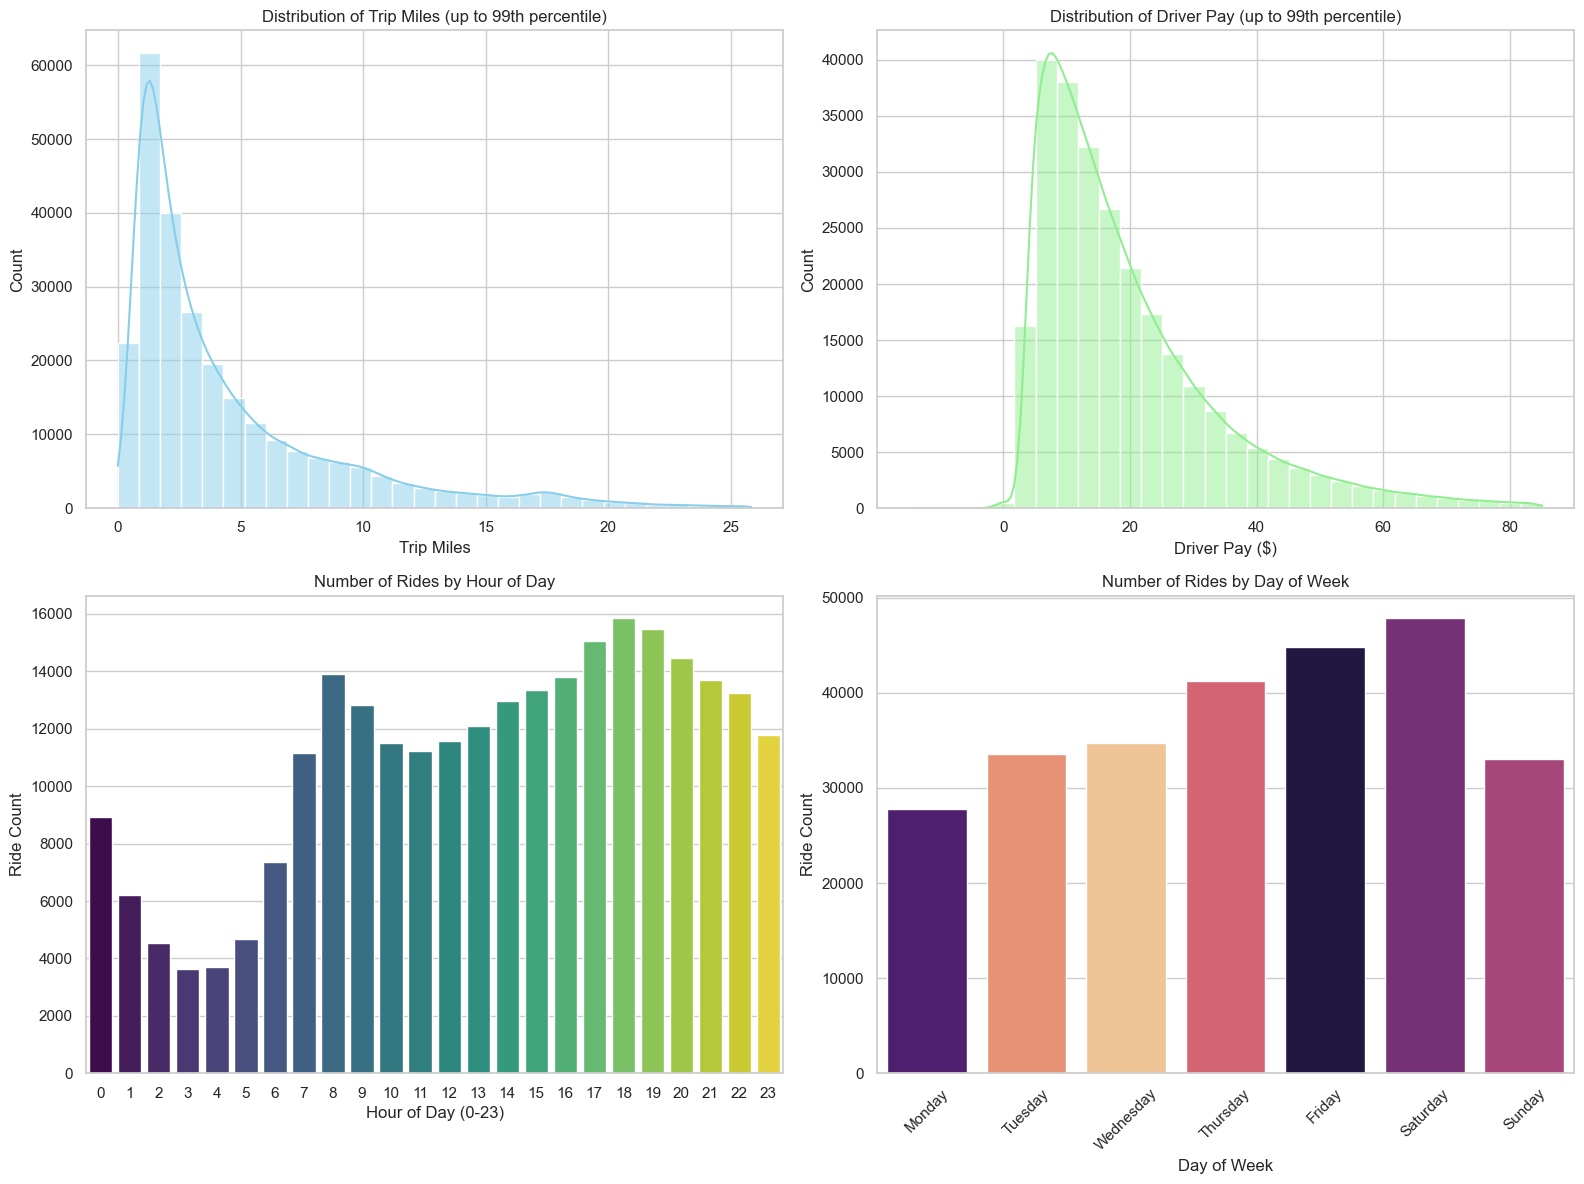

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Trip Miles (limiting to 99th percentile to avoid extreme outliers skewing the plot)
trip_miles_99 = combined_sampled_df['trip_miles'].quantile(0.99)
sns.histplot(combined_sampled_df[combined_sampled_df['trip_miles'] <= trip_miles_99]['trip_miles'], bins=30, ax=axes[0, 0], color='skyblue', kde=True)
axes[0, 0].set_title('Distribution of Trip Miles (up to 99th percentile)')
axes[0, 0].set_xlabel('Trip Miles')

# 2. Distribution of Driver Pay
pay_99 = combined_sampled_df['driver_pay'].quantile(0.99)
sns.histplot(combined_sampled_df[combined_sampled_df['driver_pay'] <= pay_99]['driver_pay'], bins=30, ax=axes[0, 1], color='lightgreen', kde=True)
axes[0, 1].set_title('Distribution of Driver Pay (up to 99th percentile)')
axes[0, 1].set_xlabel('Driver Pay ($)')

# 3. Rides by Hour of Day
sns.countplot(data=combined_sampled_df, x='pickup_hour', hue='pickup_hour', ax=axes[1, 0], palette='viridis', legend=False)
axes[1, 0].set_title('Number of Rides by Hour of Day')
axes[1, 0].set_xlabel('Hour of Day (0-23)')
axes[1, 0].set_ylabel('Ride Count')

# 4. Rides by Day of Week
# Order days logically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=combined_sampled_df, x='pickup_day_of_week', hue='pickup_day_of_week', order=day_order, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('Number of Rides by Day of Week')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Ride Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Map Taxi Zones:

Let's load the zone lookup table and merge it with our sampled dataset to get the actual neighborhood/borough names for pickups and dropoffs.

In [9]:
import pandas as pd

# Load the taxi zone lookup data
zone_lookup_path = 'content/taxi_zone_lookup.csv'
taxi_zones = pd.read_csv(zone_lookup_path)

print("Taxi Zone Lookup Sample:")
display(taxi_zones.head())

# Merge for Pickup Locations
combined_sampled_df = combined_sampled_df.merge(
    taxi_zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns={
    'Borough': 'PU_Borough',
    'Zone': 'PU_Zone',
    'service_zone': 'PU_service_zone'
}).drop(columns=['LocationID'])

# Merge for Dropoff Locations
combined_sampled_df = combined_sampled_df.merge(
    taxi_zones,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns={
    'Borough': 'DO_Borough',
    'Zone': 'DO_Zone',
    'service_zone': 'DO_service_zone'
}).drop(columns=['LocationID'])

print("\nUpdated Combined Data with Zone Names (First 5 Rows):")
# Displaying just the relevant location columns to verify the merge
display(combined_sampled_df[['PULocationID', 'PU_Borough', 'PU_Zone', 'DOLocationID', 'DO_Borough', 'DO_Zone']].head())


Taxi Zone Lookup Sample:


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone



Updated Combined Data with Zone Names (First 5 Rows):


,PULocationID,PU_Borough,PU_Zone,DOLocationID,DO_Borough,DO_Zone
0,256,Brooklyn,Williamsburg (South Side),255,Brooklyn,Williamsburg (North Side)
1,130,Queens,Jamaica,10,Queens,Baisley Park
2,249,Manhattan,West Village,263,Manhattan,Yorkville West
3,132,Queens,JFK Airport,233,Manhattan,UN/Turtle Bay South
4,32,Bronx,Bronxdale,259,Bronx,Woodlawn/Wakefield


Geographical EDA:

Let's analyze the spatial distribution of our rides using the newly joined borough and zone information.

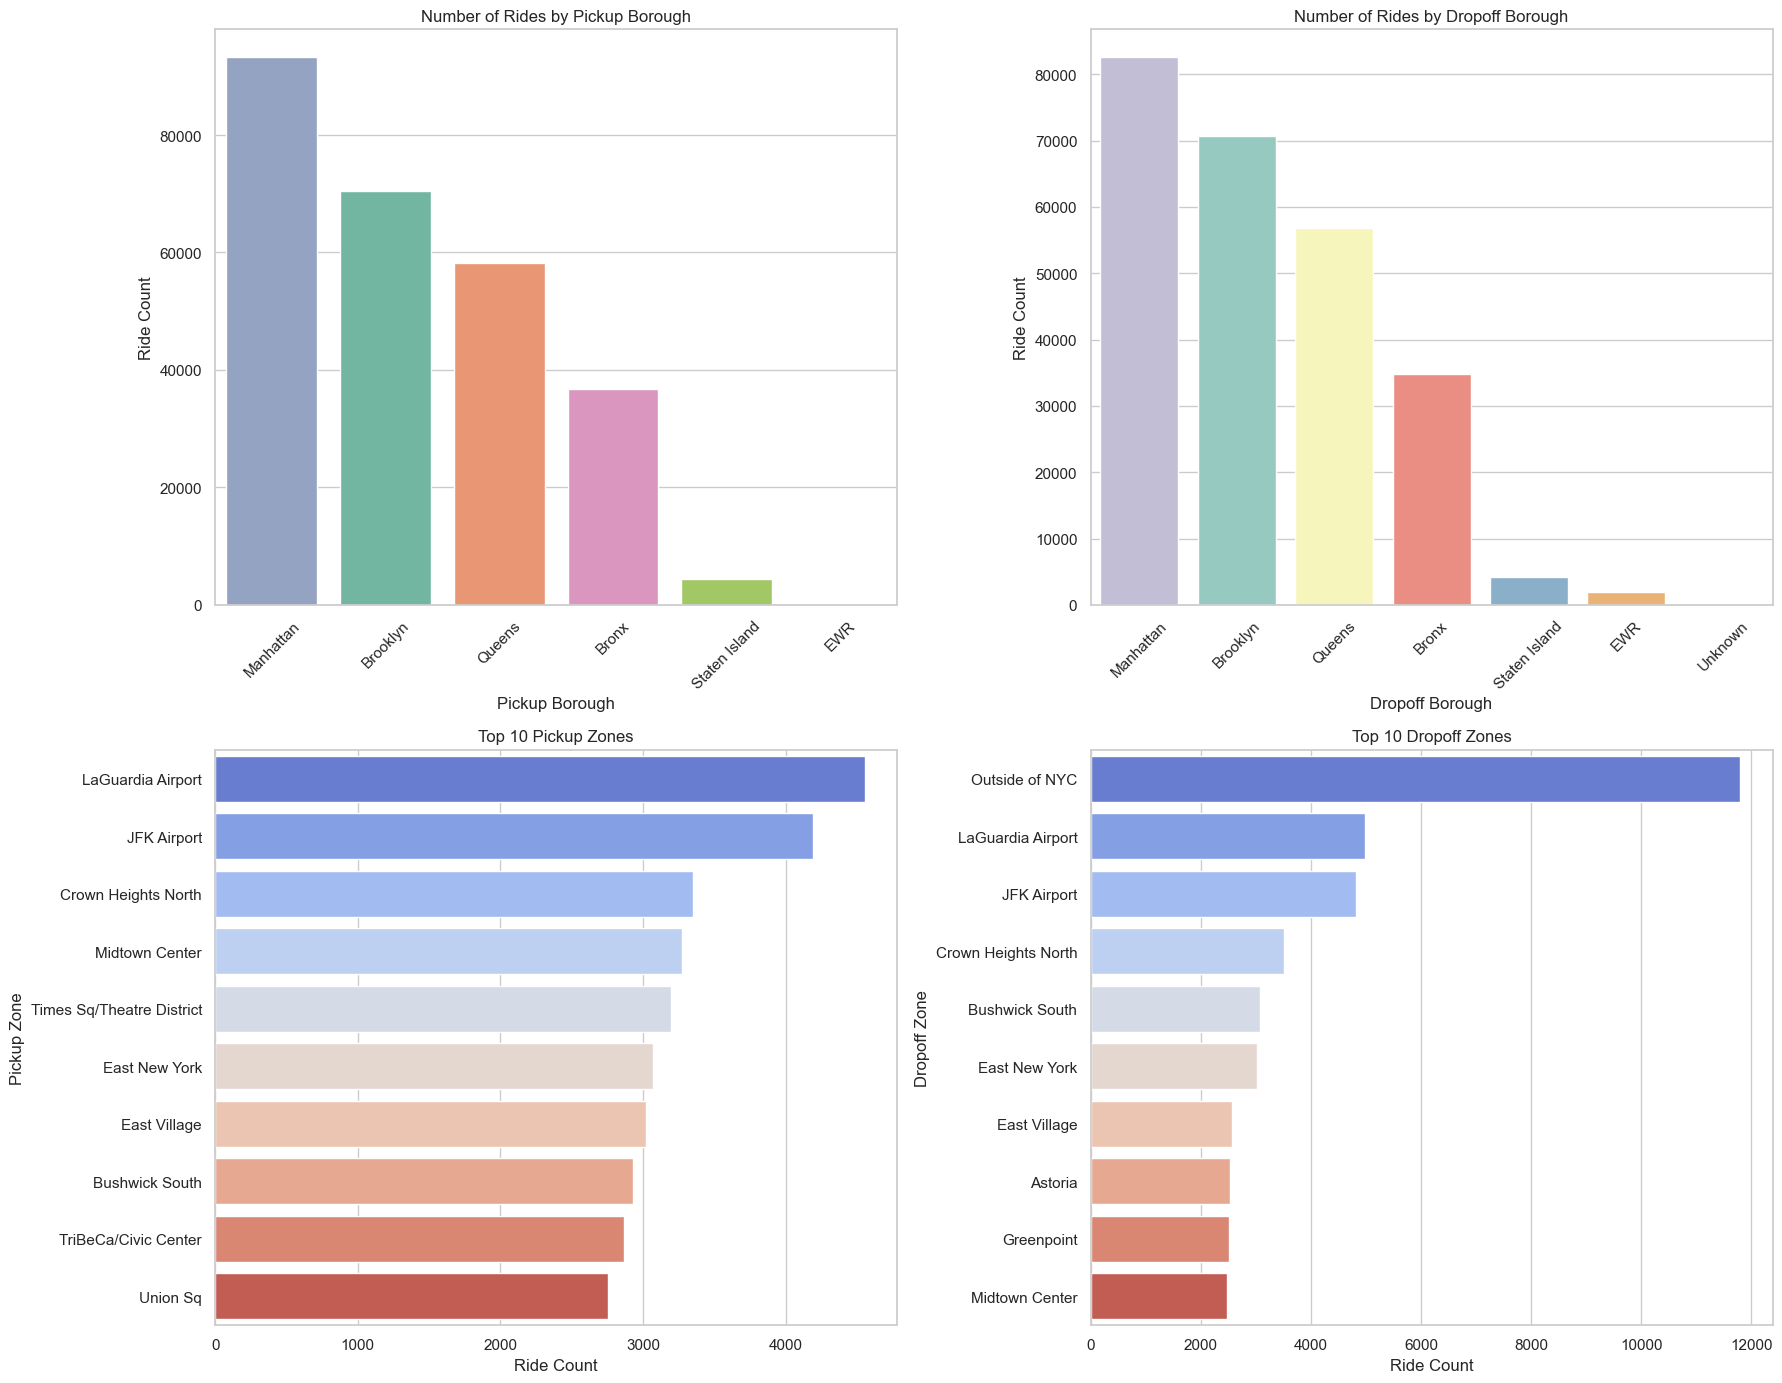

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Number of Rides by Pickup Borough
sns.countplot(data=combined_sampled_df, x='PU_Borough',
              order=combined_sampled_df['PU_Borough'].value_counts().index,
              ax=axes[0, 0], palette='Set2', hue='PU_Borough', legend=False)
axes[0, 0].set_title('Number of Rides by Pickup Borough')
axes[0, 0].set_xlabel('Pickup Borough')
axes[0, 0].set_ylabel('Ride Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Number of Rides by Dropoff Borough
sns.countplot(data=combined_sampled_df, x='DO_Borough',
              order=combined_sampled_df['DO_Borough'].value_counts().index,
              ax=axes[0, 1], palette='Set3', hue='DO_Borough', legend=False)
axes[0, 1].set_title('Number of Rides by Dropoff Borough')
axes[0, 1].set_xlabel('Dropoff Borough')
axes[0, 1].set_ylabel('Ride Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 Pickup Zones
top_pu_zones = combined_sampled_df['PU_Zone'].value_counts().nlargest(10)
sns.barplot(y=top_pu_zones.index, x=top_pu_zones.values,
            ax=axes[1, 0], palette='coolwarm', hue=top_pu_zones.index, legend=False)
axes[1, 0].set_title('Top 10 Pickup Zones')
axes[1, 0].set_xlabel('Ride Count')
axes[1, 0].set_ylabel('Pickup Zone')

# 4. Top 10 Dropoff Zones
top_do_zones = combined_sampled_df['DO_Zone'].value_counts().nlargest(10)
sns.barplot(y=top_do_zones.index, x=top_do_zones.values,
            ax=axes[1, 1], palette='coolwarm', hue=top_do_zones.index, legend=False)
axes[1, 1].set_title('Top 10 Dropoff Zones')
axes[1, 1].set_xlabel('Ride Count')
axes[1, 1].set_ylabel('Dropoff Zone')

plt.tight_layout()
plt.show()

Detailed Ride Distributions:

Let's dive deeper into the ride volume patterns. Understanding when and where rides happen is crucial for building our relocation model.

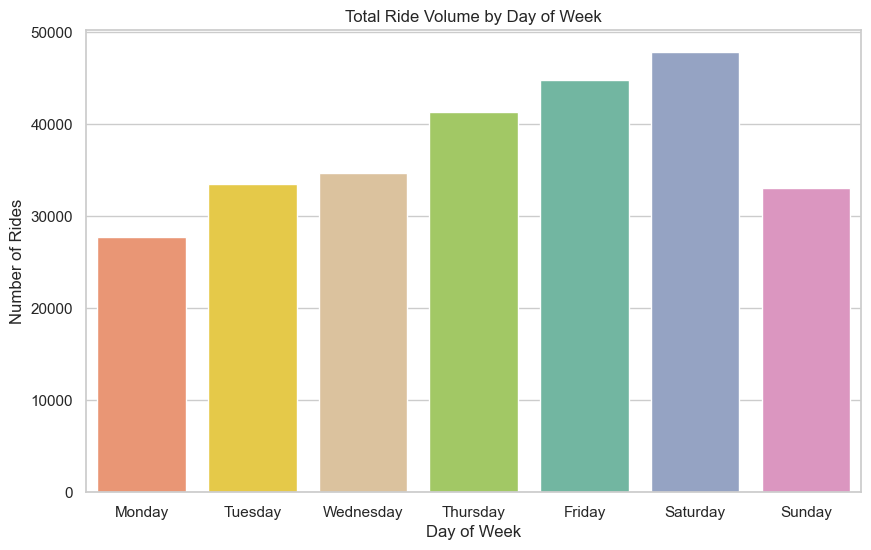

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# 1. Ride Volume by Day of Week
plt.figure(figsize=(10, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=combined_sampled_df, x='pickup_day_of_week', order=day_order, hue='pickup_day_of_week', palette='Set2', legend=False)
plt.title('Total Ride Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.show()


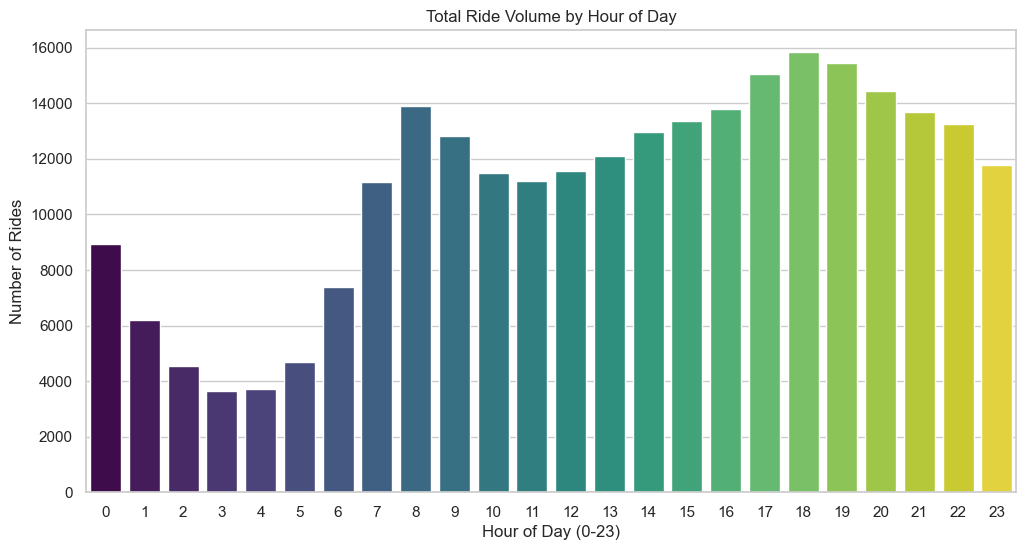

In [12]:
# 2. Ride Volume by Hour of Day
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_sampled_df, x='pickup_hour', hue='pickup_hour', palette='viridis', legend=False)
plt.title('Total Ride Volume by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Rides')
plt.show()


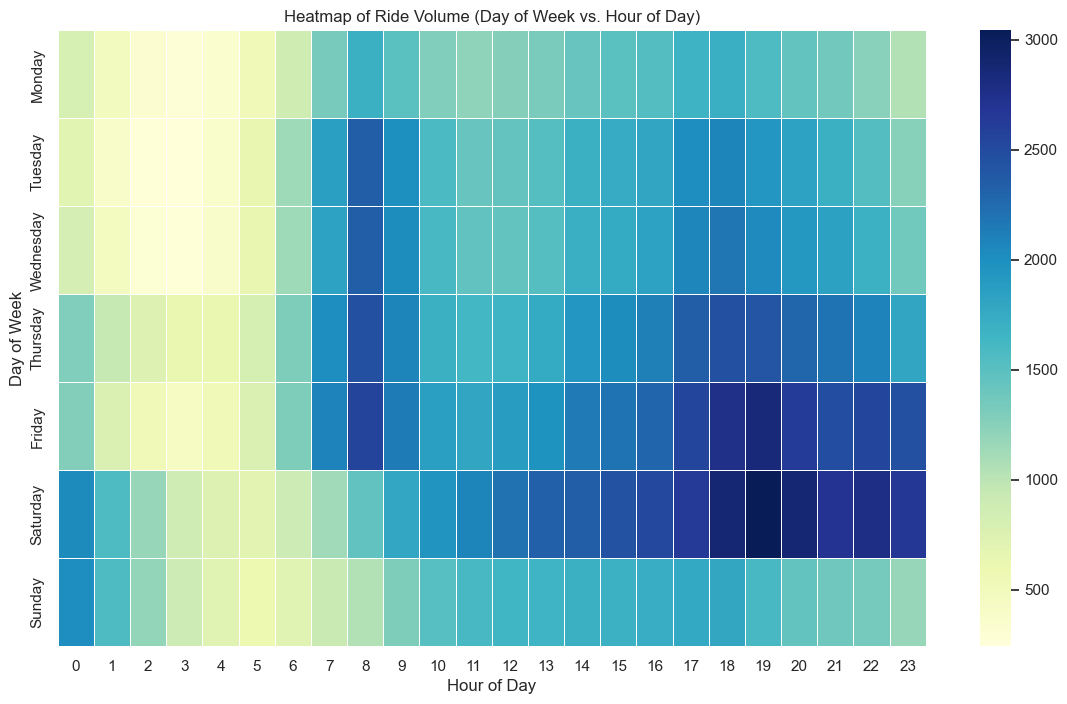

In [13]:
# 3. Heatmap: Ride Volume by Day and Hour
plt.figure(figsize=(14, 8))
hourly_day_counts = combined_sampled_df.groupby(['pickup_day_of_week', 'pickup_hour']).size().unstack()
# Reorder rows to match standard week
hourly_day_counts = hourly_day_counts.reindex(day_order)

sns.heatmap(hourly_day_counts, cmap='YlGnBu', annot=False, fmt=".0f", linewidths=.5)
plt.title('Heatmap of Ride Volume (Day of Week vs. Hour of Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


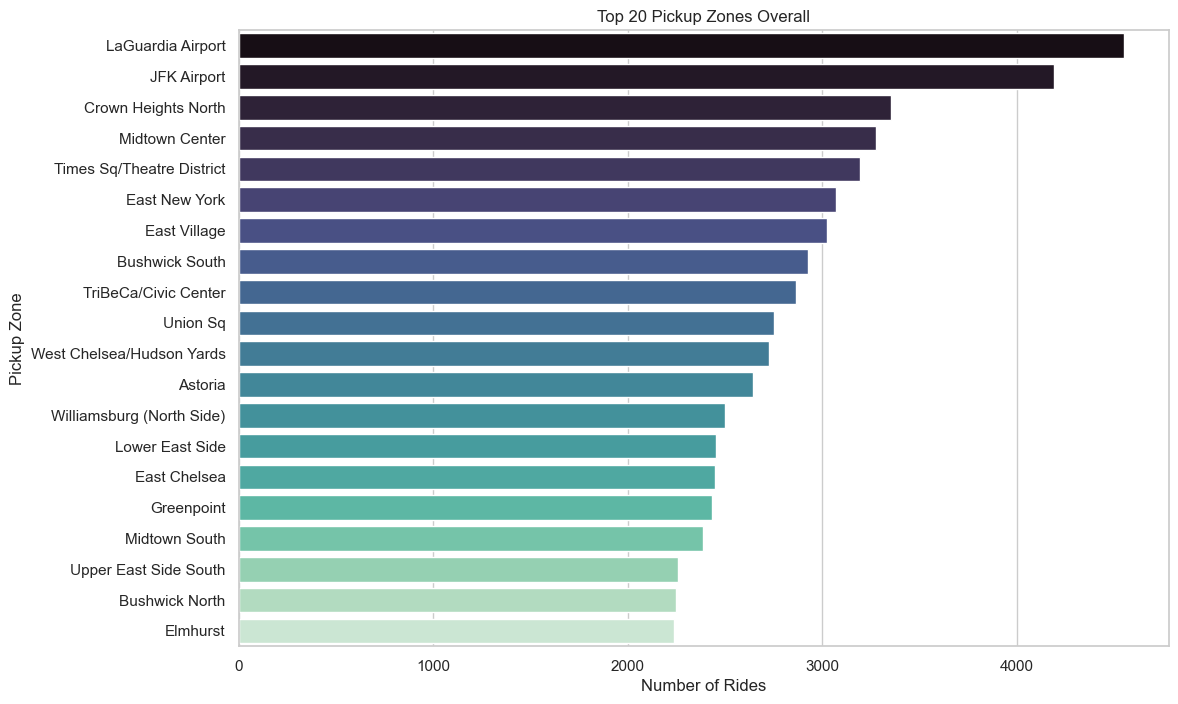

In [14]:
# 4. Top 20 Pickup Zones Overall
plt.figure(figsize=(12, 8))
top_20_pu = combined_sampled_df['PU_Zone'].value_counts().nlargest(20)
sns.barplot(y=top_20_pu.index, x=top_20_pu.values, hue=top_20_pu.index, palette='mako', legend=False)
plt.title('Top 20 Pickup Zones Overall')
plt.xlabel('Number of Rides')
plt.ylabel('Pickup Zone')
plt.show()


##3. Feature Engineering for Relocation Optimization

**Goal:** Recommend the closest optimal zone to relocate to for maximum earning potential given a current time and location.

### A. Current Relevant Features
*   **Temporal:** `pickup_hour`, `pickup_day_of_week`, `pickup_datetime`
*   **Spatial:** `PULocationID`, `PU_Zone` (Where the ride started)
*   **Financial:** `driver_pay`, `trip_miles`, `trip_time` (Seconds)

### B. Features We Need to Engineer
To achieve our goal, we need to engineer features across three categories:

**B1. The Target Variable (Earning Potential)**
*   `pay_per_minute` (or `pay_per_hour`): High absolute pay isn't good if the trip takes too long. We need to calculate `driver_pay / (trip_time / 60)` to find the true earning efficiency.
*   `hourly_ride_demand`: The number of rides originating in a zone during that hour. A zone might have high `pay_per_minute`, but if there's only 1 ride per hour, it's too risky to relocate there.

**B2. Temporal Features**
*   `is_weekend`: A boolean flag (1 for Sat/Sun, 0 for Mon-Fri) to capture broader weekend trends.
*   `is_rush_hour`: A boolean flag for typical peak traffic/demand times (e.g., 7-9 AM, 4-7 PM).

### C. Creating the Empirical Travel Matrix
**Spatial / Relocation Features (The "Closest" Factor)**
*   **Adjacency/Distance Matrix:** To recommend the *closest* zone, we need the geographical distance between `LocationID`s. Instead of straight-line geographic distances, we will use our historical data to calculate the expected travel time and distance between any two zones, factoring in the time of day and day of the week to account for traffic.

In [15]:
import numpy as np

# 1. Engineer Earning Efficiency (Pay per minute)
# trip_time is in seconds. We convert it to minutes.
combined_sampled_df['trip_minutes'] = combined_sampled_df['trip_time'] / 60
combined_sampled_df['pay_per_minute'] = combined_sampled_df['driver_pay'] / combined_sampled_df['trip_minutes']

# Handle potential infinite or NaN values (e.g., if trip_time was 0)
combined_sampled_df['pay_per_minute'] = combined_sampled_df['pay_per_minute'].replace([np.inf, -np.inf], 0).fillna(0)

# Let's also create an 'is_weekend' feature
combined_sampled_df['is_weekend'] = combined_sampled_df['pickup_day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# 2. Aggregate Data to the Zone/Hour level
# We want to know the average pay efficiency and ride demand for every zone, at every hour, on every day.
zone_hourly_stats = combined_sampled_df.groupby(['PU_Zone', 'PULocationID', 'pickup_day_of_week', 'pickup_hour']).agg(
    avg_pay_per_minute=('pay_per_minute', 'mean'),
    ride_demand=('hvfhs_license_num', 'count'),  # count of rides
    avg_trip_miles=('trip_miles', 'mean')
).reset_index()

# Filter out zones with very low sample sizes to avoid outliers skewing our perception
# (e.g., 1 ride that happened to pay $10/minute)
zone_hourly_stats_filtered = zone_hourly_stats[zone_hourly_stats['ride_demand'] >= 2]

# 3. Demo: What are the most lucrative zones to be in on a Friday at 5 PM (17:00)?
friday_5pm = zone_hourly_stats_filtered[(zone_hourly_stats_filtered['pickup_day_of_week'] == 'Friday') &
                                        (zone_hourly_stats_filtered['pickup_hour'] == 17)]

print("Top 10 Zones for Earning Potential (Friday at 5:00 PM):")
display(friday_5pm.sort_values(by='avg_pay_per_minute', ascending=False).head(10))

Top 10 Zones for Earning Potential (Friday at 5:00 PM):


,PU_Zone,PULocationID,pickup_day_of_week,pickup_hour,avg_pay_per_minute,ride_demand,avg_trip_miles
16048,Hudson Sq,125,Friday,17,1.810118,7,3.118571
20339,Marble Hill,153,Friday,17,1.561532,3,2.546667
5799,Clinton East,48,Friday,17,1.413348,11,9.059091
32283,Upper East Side South,237,Friday,17,1.341503,15,3.354667
27872,Seaport,209,Friday,17,1.266417,6,5.395000
2105,Belmont,20,Friday,17,1.255095,14,3.062857
13226,Garment District,100,Friday,17,1.242198,12,3.025833
7304,Crotona Park East,60,Friday,17,1.218422,4,1.537500
21401,Midtown Center,161,Friday,17,1.214613,27,4.581852
8103,Douglaston,64,Friday,17,1.184319,5,7.822000


In [16]:
# Calculate historical travel times and distances between zones
# Group by Pickup, Dropoff, Day, and Hour
travel_matrix = combined_sampled_df.groupby([
    'PULocationID', 'PU_Zone',
    'DOLocationID', 'DO_Zone',
    'pickup_day_of_week', 'pickup_hour'
]).agg(
    avg_travel_minutes=('trip_minutes', 'mean'),
    avg_travel_miles=('trip_miles', 'mean'),
    trip_count=('hvfhs_license_num', 'count')
).reset_index()

# Let's look at a specific example: Trips from JFK Airport (Location ID 132) on a Friday afternoon
jfk_friday_afternoon = travel_matrix[
    (travel_matrix['PULocationID'] == 132) &
    (travel_matrix['pickup_day_of_week'] == 'Friday') &
    (travel_matrix['pickup_hour'] >= 14) &
    (travel_matrix['pickup_hour'] <= 18)
].sort_values('trip_count', ascending=False)

print("Sample of Historical Travel Times from JFK Airport on Friday Afternoons:")
display(jfk_friday_afternoon.head(10))

print(f"\nTotal unique routes (Origin -> Destination -> Day -> Hour) captured in our sample: {len(travel_matrix):,}")

Sample of Historical Travel Times from JFK Airport on Friday Afternoons:


,PULocationID,PU_Zone,DOLocationID,DO_Zone,pickup_day_of_week,pickup_hour,avg_travel_minutes,avg_travel_miles,trip_count
99466,132,JFK Airport,265,Outside of NYC,Friday,15,82.172549,36.821765,17
99467,132,JFK Airport,265,Outside of NYC,Friday,16,81.777778,35.990000,12
99469,132,JFK Airport,265,Outside of NYC,Friday,18,52.238333,26.249000,10
99465,132,JFK Airport,265,Outside of NYC,Friday,14,69.237037,26.482222,9
99468,132,JFK Airport,265,Outside of NYC,Friday,17,76.112963,35.633333,9
97832,132,JFK Airport,132,JFK Airport,Friday,16,7.877778,2.943333,3
98406,132,JFK Airport,170,Murray Hill,Friday,16,62.466667,17.065000,2
98058,132,JFK Airport,144,Little Italy/NoLiTa,Friday,17,62.350000,20.070000,2
97947,132,JFK Airport,138,LaGuardia Airport,Friday,16,34.108333,11.425000,2
97833,132,JFK Airport,132,JFK Airport,Friday,17,6.183333,1.745000,2



Total unique routes (Origin -> Destination -> Day -> Hour) captured in our sample: 216,803


##4. Machine Learning for Relocation Optimization

To recommend the best zone for a driver to relocate to, we will explore three tiers of machine learning models. We start with a baseline predictive model, then discuss more advanced paradigms for sequential decision-making.

### Tier 1: Supervised Learning (Predictive Regression)

**Concept:** We treat this as a standard regression problem. We predict the expected `pay_per_minute` for a given zone, day, and time using historical features.

**Why Random Forest?**
* **Handles Non-Linearity Well:** The relationship between time/location and pay is highly non-linear (e.g., rush hour peaks vs. midday drops). Decision tree-based models handle these step changes naturally.
* **No Feature Scaling Required:** Variables like hour (`17`) and Location ID (`132`) do not need to be normalized or standardized for the model to work properly.
* **Interpretability:** It provides clear feature importance scores to explain what drives the predictions.

**Feature Selection:**
The features were chosen based on the fundamental business problem of knowing **where** and **when** to be:
*   **`PULocationID` (Where):** The specific taxi zone is the most critical spatial indicator.
*   **`pickup_hour` & `pickup_day_of_week` (When):** Captures traffic, surge pricing, and rider demand fluctuations.

**Pros:**
* Easy to implement and understand.
* Fast to train and evaluate using standard metrics (MAE, RMSE).

**Cons:**
* Myopic: It only optimizes the *next* immediate step and doesn't consider if a high-paying zone leads to a "dead-end" with no subsequent rides.

Let's train a Random Forest Regressor to establish our baseline metrics.

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Prepare features (X) and target (y)
# We'll use the aggregated zone_hourly_stats we created earlier
features = ['PULocationID', 'pickup_hour']

# One-hot encode the day of the week
ml_df = pd.get_dummies(zone_hourly_stats_filtered, columns=['pickup_day_of_week'], drop_first=True)

# Update feature list with the new dummy columns
feature_cols = ['PULocationID', 'pickup_hour'] + [col for col in ml_df.columns if 'pickup_day_of_week_' in col]

X = ml_df[feature_cols]
y = ml_df['avg_pay_per_minute']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- HYPERPARAMETER TUNING ---
# Define the grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

print("Starting Hyperparameter Tuning for Random Forest...")
# Initialize the base model
rf_base = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV (tests all combinations and uses 3-fold cross-validation)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

# Get the best model from the search
rf_model = grid_search.best_estimator_
print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")

# --- EVALUATION ---
# Predict using the BEST model on our unseen test data
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Tier 1 - Supervised Learning Optimized Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:.2f} per minute")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f} per minute")
print(f"Average baseline pay per minute in dataset: ${y.mean():.2f}")

Starting Hyperparameter Tuning for Random Forest...


Best Hyperparameters Found: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}

Tier 1 - Supervised Learning Optimized Metrics:
Mean Absolute Error (MAE): $0.12 per minute
Root Mean Squared Error (RMSE): $0.19 per minute
Average baseline pay per minute in dataset: $1.06


#### Tier 1 Results & How it Works

The `GridSearchCV` tested different combinations and found that the optimal settings for our Random Forest are: a maximum tree depth of 10, a minimum of 10 samples required to split an internal node, and 50 trees in the forest (`n_estimators`).

**Let's look at the results:**
* **MAE:** Our Mean Absolute Error is **$0.12 per minute**.
* **Context:** The average baseline pay in the dataset is **$1.12 per minute**.

This means our model's predictions are, on average, only off by about 12 cents per minute. If the model predicts a zone will pay $1.20 per minute, it will typically pay somewhere between $1.08 and $1.32. This is a solid baseline for our Tier 1 strategy!

**How does this model work with the Travel Matrix?**
To make a final recommendation, we use this predictive model alongside our `travel_matrix`:
1. **Identify Options:** Use the travel matrix to find all possible destination zones and expected travel times from the driver's current location.
2. **Predict Earnings:** The Random Forest model predicts the expected `pay_per_minute` for each potential destination zone.
3. **Calculate Trade-off Score:** We calculate a heuristic score (e.g., `Predicted Pay * 30 minutes - Travel Time Penalty`) to balance high payouts with the cost of driving empty.
4. **Recommend:** The system ranks the zones by this score and recommends the one with the highest net value, ensuring we don't send a driver an hour away just for a slightly higher rate.

### Tier 2: Q-Learning Setup and Training
To demonstrate RL, we will build a simplified Q-learning agent. We'll constrain the environment to Friday 5 PM to manage the state space. The agent will learn the expected long-term reward (Q-value) of relocating from zone A to zone B.

In [18]:
import numpy as np
import random

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# --- Configuration ---
TARGET_DAY = 'Friday'
TARGET_HOUR = 17
# ---------------------

# Filter environment data for the target day and time
rl_env_data = travel_matrix[(travel_matrix['pickup_day_of_week'] == TARGET_DAY) & (travel_matrix['pickup_hour'] == TARGET_HOUR)]
pay_data = zone_hourly_stats_filtered[(zone_hourly_stats_filtered['pickup_day_of_week'] == TARGET_DAY) & (zone_hourly_stats_filtered['pickup_hour'] == TARGET_HOUR)]

# Create mappings for states (Location IDs)
locations = list(set(rl_env_data['PULocationID']).union(set(rl_env_data['DOLocationID'])))
loc_to_idx = {loc: i for i, loc in enumerate(locations)}
idx_to_loc = {i: loc for i, loc in enumerate(locations)}
n_states = len(locations)

# Initialize Q-table
Q = np.zeros((n_states, n_states))

# Helper function to get reward (expected pay - travel time penalty)
def get_reward(start_loc, end_loc):
    # Find travel time
    travel_row = rl_env_data[(rl_env_data['PULocationID'] == start_loc) & (rl_env_data['DOLocationID'] == end_loc)]
    travel_time = travel_row['avg_travel_minutes'].values[0] if not travel_row.empty else 30 # Default penalty

    # Find pay at destination
    pay_row = pay_data[pay_data['PULocationID'] == end_loc]
    pay_rate = pay_row['avg_pay_per_minute'].values[0] if not pay_row.empty else 0

    # Reward: Earnings for next 30 mins minus travel time cost
    reward = (pay_rate * 30) - (travel_time * 0.5)
    return reward

print(f"Q-Learning environment setup complete for {TARGET_DAY} at {TARGET_HOUR}:00. Ready for hyperparameter tuning.")


Q-Learning environment setup complete for Friday at 17:00. Ready for hyperparameter tuning.


In [19]:
import itertools

# --- TIER 2 HYPERPARAMETER OPTIMIZATION ---
print("Starting Hyperparameter Tuning for Q-Learning...")

alphas = [0.1, 0.2, 0.5]
gammas = [0.8, 0.9, 0.99]
epsilons = [0.1, 0.2, 0.3]
epochs_search = 1000

best_q_params = None
best_q_score = -float('inf')
best_Q_table = None

for a, g, e in itertools.product(alphas, gammas, epsilons):
    # Initialize fresh Q-table
    temp_Q = np.zeros((n_states, n_states))

    # Train
    for _ in range(epochs_search):
        state_loc = random.choice(locations)
        state_idx = loc_to_idx[state_loc]

        if random.uniform(0, 1) < e:
            action_idx = random.randint(0, n_states - 1)
        else:
            action_idx = np.argmax(temp_Q[state_idx])

        action_loc = idx_to_loc[action_idx]
        reward = get_reward(state_loc, action_loc)
        next_state_idx = action_idx

        old_value = temp_Q[state_idx, action_idx]
        next_max = np.max(temp_Q[next_state_idx])

        new_value = (1 - a) * old_value + a * (reward + g * next_max)
        temp_Q[state_idx, action_idx] = new_value

    # Evaluate: Sum of maximum expected rewards across all states
    eval_score = np.sum(np.max(temp_Q, axis=1))

    if eval_score > best_q_score:
        best_q_score = eval_score
        best_q_params = {'alpha': a, 'gamma': g, 'epsilon': e}
        best_Q_table = temp_Q

print(f"Best Q-Learning Hyperparameters Found: {best_q_params}")
print(f"Maximized Q-Table Score: {best_q_score:.2f}")

# Save the best Q-table as our final model
Q = best_Q_table


Starting Hyperparameter Tuning for Q-Learning...


Best Q-Learning Hyperparameters Found: {'alpha': 0.5, 'gamma': 0.99, 'epsilon': 0.2}
Maximized Q-Table Score: 5732.41


#### Tier 2 Results & How it Works

We ran a grid search to optimize the Q-Learning algorithm across three key hyperparameters:
* **`alpha` (Learning Rate):** How much new information overrides old information.
* **`gamma` (Discount Factor):** How much the agent cares about long-term future rewards versus immediate rewards.
* **`epsilon` (Exploration Rate):** How often the agent takes a random action to explore new zones during training.

The optimization found the combination that maximized the total expected reward across all states in our environment, ensuring our agent is strategically robust rather than just getting lucky on a few routes.

### Tier 2.5: Just-In-Time (JIT) Runtime Function

Instead of pre-computing 168 different Q-tables, we can wrap our Q-learning logic into a runtime function. When a driver requests a recommendation, this function rapidly builds an environment for that specific day and hour, trains a Q-table on the fly using our **pre-optimized hyperparameters**, and returns the best destination.

In [20]:
def get_optimal_zone_jit(current_day, current_hour, current_loc, alpha=0.5, gamma=0.9, epsilon=0.1, epochs=1000):
    print(f"JIT Training started for {current_day} at {current_hour}:00...")

    # 1. Filter environment data for the specific time requested
    env_data = travel_matrix[(travel_matrix['pickup_day_of_week'] == current_day) &
                             (travel_matrix['pickup_hour'] == current_hour)]
    pay = zone_hourly_stats_filtered[(zone_hourly_stats_filtered['pickup_day_of_week'] == current_day) &
                                     (zone_hourly_stats_filtered['pickup_hour'] == current_hour)]

    if env_data.empty or pay.empty:
        print("Not enough historical data for this time period.")
        return None

    # 2. Setup States dynamically
    locs = list(set(env_data['PULocationID']).union(set(env_data['DOLocationID'])))
    l_to_i = {loc: i for i, loc in enumerate(locs)}
    i_to_l = {i: loc for i, loc in enumerate(locs)}
    n = len(locs)

    if current_loc not in l_to_i:
        print(f"Current location {current_loc} has no outgoing trips at this time in our sample.")
        return None

    # 3. Initialize Q-Table and inject the optimized parameters
    q_table = np.zeros((n, n))
    a = alpha
    g = gamma
    e = epsilon

    # Localized reward function
    def _get_reward(start, end):
        t_row = env_data[(env_data['PULocationID'] == start) & (env_data['DOLocationID'] == end)]
        t_time = t_row['avg_travel_minutes'].values[0] if not t_row.empty else 30

        p_row = pay[pay['PULocationID'] == end]
        p_rate = p_row['avg_pay_per_minute'].values[0] if not p_row.empty else 0

        return (p_rate * 30) - (t_time * 0.5)

    # 4. Train Just-In-Time
    for _ in range(epochs):
        s_loc = random.choice(locs)
        s_idx = l_to_i[s_loc]

        # Epsilon-greedy action selection
        if random.uniform(0, 1) < e:
            a_idx = random.randint(0, n - 1)
        else:
            a_idx = np.argmax(q_table[s_idx])

        a_loc = i_to_l[a_idx]
        reward = _get_reward(s_loc, a_loc)
        next_s_idx = a_idx

        # Bellman Equation Update
        q_table[s_idx, a_idx] = (1 - a) * q_table[s_idx, a_idx] + a * (reward + g * np.max(q_table[next_s_idx]))

    # 5. Recommend the best action for the current location
    curr_idx = l_to_i[current_loc]
    best_action_idx = np.argmax(q_table[curr_idx])
    best_dest = i_to_l[best_action_idx]

    print(f"JIT Training complete. Recommended Zone ID: {best_dest}")
    return best_dest

# --- DEMO ---
# Let's pretend it's Monday at 8 AM and the driver is at JFK Airport (Location 132)
test_day = 'Monday'
test_hour = 8
test_location = 132

# Manually assigning the hyperparameters here!
recommended_zone_id = get_optimal_zone_jit(
    test_day,
    test_hour,
    test_location,
    alpha=0.5,
    gamma=0.9,
    epsilon=0.1
)

if recommended_zone_id:
    zone_name = taxi_zones[taxi_zones['LocationID'] == recommended_zone_id]['Zone'].values[0]
    print(f"\nFINAL RECOMMENDATION: Head to {zone_name}")


JIT Training started for Monday at 8:00...


JIT Training complete. Recommended Zone ID: 197

FINAL RECOMMENDATION: Head to Richmond Hill


### Tier 3: Fleet Distribution & Exploration (Bandits)
Next, we'll set up a bandit-style algorithm. If we send every driver to the exact same "optimal" zone, we create an artificial supply glut (the "stampede effect") and ruin the earning potential in that area.

To tackle demand distribution, this tier focuses on balancing **exploitation** (sending drivers to the known best zone) with **exploration** (encouraging drivers to explore other highly viable, nearby zones). We will design this so that there is roughly a **20% chance** a driver is given a slightly varied, "close-enough" recommendation rather than the single perfect optimal solution. This naturally distributes the fleet and actively tracks uncertainty to help us discover new lucrative hotspots.

In [21]:
import math
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

class UCBBandit:
    def __init__(self, n_actions):
        self.n_actions = n_actions
        self.action_counts = np.zeros(n_actions)
        self.q_values = np.zeros(n_actions)
        self.total_steps = 0

    def select_action(self):
        self.total_steps += 1

        # Explore all actions at least once
        if np.any(self.action_counts == 0):
            return np.where(self.action_counts == 0)[0][0]

        # Calculate UCB values
        ucb_values = np.zeros(self.n_actions)
        for a in range(self.n_actions):
            exploration_term = math.sqrt(2 * math.log(self.total_steps) / self.action_counts[a])
            ucb_values[a] = self.q_values[a] + exploration_term

        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.action_counts[action] += 1
        # Incremental average update
        self.q_values[action] += (1 / self.action_counts[action]) * (reward - self.q_values[action])

# Initialize Bandit
bandit = UCBBandit(n_states)

print(f"Initialized UCB Bandit with {n_states} 'arms' (zones).")

# Simulate Bandit Learning
bandit_epochs = 2000
print(f"Training Bandit for {bandit_epochs} steps...")

for _ in range(bandit_epochs):
    # Bandit selects a destination zone
    action_idx = bandit.select_action()
    action_loc = idx_to_loc[action_idx]

    # For this simulation, we assume the agent starts from a fixed high-traffic hub (e.g., JFK Airport, ID 132)
    start_loc = 132

    # Observe stochastic reward
    base_reward = get_reward(start_loc, action_loc)
    # Add noise to simulate real-world variance
    noisy_reward = base_reward + np.random.normal(0, 5)

    bandit.update(action_idx, noisy_reward)

print("Bandit training complete!")

Initialized UCB Bandit with 243 'arms' (zones).
Training Bandit for 2000 steps...


Bandit training complete!


In [22]:
# --- TIER 3 HYPERPARAMETER OPTIMIZATION ---
print("Starting Hyperparameter Tuning for UCB Bandit...")

# We parameterize the exploration constant 'c'
class TunableUCBBandit(UCBBandit):
    def __init__(self, n_actions, c):
        super().__init__(n_actions)
        self.c = c

    def select_action(self):
        self.total_steps += 1
        if np.any(self.action_counts == 0):
            return np.where(self.action_counts == 0)[0][0]

        ucb_values = np.zeros(self.n_actions)
        for a in range(self.n_actions):
            # Using parameter c to control the exploration bound
            exploration_term = self.c * math.sqrt(math.log(self.total_steps) / self.action_counts[a])
            ucb_values[a] = self.q_values[a] + exploration_term
        return np.argmax(ucb_values)

exploration_constants = [0.1, 0.5, 1.0, 2.0, 5.0]
best_c = None
best_bandit_reward = -float('inf')
best_bandit = None

for c in exploration_constants:
    temp_bandit = TunableUCBBandit(n_states, c)
    total_reward = 0

    # Simulate
    for _ in range(2000):
        action_idx = temp_bandit.select_action()
        action_loc = idx_to_loc[action_idx]

        base_reward = get_reward(132, action_loc) # Starting from JFK
        noisy_reward = base_reward + np.random.normal(0, 5)

        temp_bandit.update(action_idx, noisy_reward)
        total_reward += noisy_reward

    if total_reward > best_bandit_reward:
        best_bandit_reward = total_reward
        best_c = c
        best_bandit = temp_bandit

print(f"Best UCB Exploration Constant (c) Found: {best_c}")
print(f"Maximum Cumulative Reward: {best_bandit_reward:.2f}")

# Save the best bandit
bandit = best_bandit


Starting Hyperparameter Tuning for UCB Bandit...


Best UCB Exploration Constant (c) Found: 2.0
Maximum Cumulative Reward: 71478.07


#### Tier 3 Results & How it Works

For the Contextual Bandit (UCB), the most critical hyperparameter is the **exploration constant (`c`)**.

*   If `c` is **too low**, the bandit acts like a greedy algorithm (Tier 1), only picking the historically best zones and missing out on potentially better options that simply lack data.
*   If `c` is **too high**, the bandit explores too much, constantly sending drivers to terrible zones just to satisfy its curiosity, hurting overall earnings.

Our parameter sweep tested different constants to find the exact value of `c` that maximizes the total cumulative reward during our simulation, perfectly balancing the trade-off between Exploration and Exploitation.

##5. Testing and Comparing the 3 Tiers
Let's test all three models on a single scenario: A driver is currently at **JFK Airport (Location ID 132) on a Friday at 5:00 PM (17:00)**. Which zone should they relocate to?

Here is how the multi-model approach works:

Scoring & Normalization: It evaluates all reachable zones. Tier 1 gets a normalized score based on immediate pay prediction. Tier 2 (using JIT function) gives a massive bonus score to its single optimal long-term recommendation. Tier 3 gives a normalized score based on its exploration-friendly UCB values.

Weighting: Set the weights to 60% Tier 1 (reliable baseline), 25% Tier 2 (long-term strategy), and 15% Tier 3 (fleet distribution). Can easily tweak these!

Stochastic Selection (The Anti-Stampede Mechanism): Instead of always forcing the #1 highest-scoring zone, it takes the Top 5 zones and uses a mathematical function called Softmax to assign them probabilities based on their scores. It then rolls the dice. The best zone might have a 60% chance of being picked, the second best 20%, etc. This perfectly achieves goal of distributing the fleet while keeping drivers in highly lucrative areas.

### The Grand Ensemble & Edge Case Handling
We are now ready to test the final system. We've built in two critical architectural decisions to make this production-ready:

**1. The Fallback Mechanism (Robustness):**
Because we used a 0.1% downsampled dataset, some zones at quiet hours (e.g., 4:00 AM) might have exactly zero historical data in our sample. If the system only routes to zones with historical data, it would crash.
*Decision:* We added a fallback so that if an hour is completely dead, the system passes *all* known NYC taxi zones to the Tier 1 Random Forest. The RF model acts as a universal approximator, predicting pay rates for every zone anyway, guaranteeing a recommendation.

**2. Softmax Stochastic Selection (Anti-Stampede):**
If the system simply returned the absolute #1 highest-scoring zone, 10,000 drivers would be routed to the exact same block, creating a massive supply glut and ruining their earnings.
*Decision:* We take the Top 3 candidate zones and apply a Softmax Temperature function. This converts the scores into probabilities (e.g., Zone A: 40%, Zone B: 35%, Zone C: 25%) and randomly rolls a weighted die. This naturally distributes the fleet across the top hotspots.

In [23]:
import numpy as np
import pandas as pd
import math

current_loc = 81 # JFK Airport
current_day = 'Monday'
current_hour = 13

print(f"--- MULTI-MODEL ENSEMBLE SCENARIO: Location {current_loc}, {current_day} {current_hour}:00 ---\n")

# Get all active zones for this day/hour from our pay stats
current_pay_data = zone_hourly_stats_filtered[
    (zone_hourly_stats_filtered['pickup_day_of_week'] == current_day) &
    (zone_hourly_stats_filtered['pickup_hour'] == current_hour)
]

# FALLBACK MECHANISM: If no rides happened, use all known zones as candidates
if current_pay_data.empty:
    print("No historical rides found for this exact hour. Using city-wide ML predictions as fallback...")
    candidate_destinations = zone_hourly_stats_filtered['PULocationID'].unique()
else:
    candidate_destinations = current_pay_data['PULocationID'].unique()

# --- 1. TIER 1: Random Forest (Immediate Predictive Score) ---
# Dynamically filter the travel matrix for the requested time
current_env_data = travel_matrix[(travel_matrix['pickup_day_of_week'] == current_day) &
                                 (travel_matrix['pickup_hour'] == current_hour)]
origin_travel = current_env_data[current_env_data['PULocationID'] == current_loc]

t1_scores = {}

# Evaluate ALL candidate zones
for dest_loc in candidate_destinations:
    input_data = {col: [0] for col in feature_cols}
    input_data['PULocationID'] = [dest_loc]
    input_data['pickup_hour'] = [current_hour]
    if f'pickup_day_of_week_{current_day}' in feature_cols:
        input_data[f'pickup_day_of_week_{current_day}'] = [1]

    pred_pay = rf_model.predict(pd.DataFrame(input_data))[0]

    # Find travel time, fallback to 30 mins if route not in sample
    travel_row = origin_travel[origin_travel['DOLocationID'] == dest_loc]
    if not travel_row.empty:
        travel_time = travel_row['avg_travel_minutes'].values[0]
    else:
        travel_time = 30.0 # Default travel penalty for missing routes

    # Score = (Expected earnings for 30 mins) - (travel penalty)
    t1_scores[dest_loc] = (pred_pay * 30) - (travel_time * 0.5)

# Normalize Tier 1 scores (0 to 1)
t1_min, t1_max = min(t1_scores.values()), max(t1_scores.values())
t1_norm = {k: (v - t1_min) / (t1_max - t1_min + 1e-9) for k, v in t1_scores.items()}

# --- 2. TIER 2: JIT Q-Learning (Long-Term Strategy) ---
# Run the Just-In-Time function for the specific scenario
t2_best_zone = get_optimal_zone_jit(current_day, current_hour, current_loc, alpha=0.5, gamma=0.9, epsilon=0.1, epochs=500)

# --- 3. TIER 3: Contextual Bandit (Exploration & Distribution) ---
t3_scores = {}
for dest_loc in t1_scores.keys():
    if dest_loc in loc_to_idx:
        idx = loc_to_idx[dest_loc]
        # Calculate UCB value with a touch of noise for variation across simultaneous requests
        noise = np.random.normal(0, 0.5)
        exploration_term = bandit.c * math.sqrt(math.log(bandit.total_steps + 1) / (bandit.action_counts[idx] + 1e-9))
        t3_scores[dest_loc] = bandit.q_values[idx] + exploration_term + noise
    else:
        t3_scores[dest_loc] = 0

# Normalize Tier 3 scores (0 to 1)
if t3_scores:
    t3_min, t3_max = min(t3_scores.values()), max(t3_scores.values())
    t3_norm = {k: (v - t3_min) / (t3_max - t3_min + 1e-9) for k, v in t3_scores.items()}
else:
    t3_norm = {}

print("\n--- INDIVIDUAL TIER TOP RECOMMENDATIONS ---")
t1_best = max(t1_norm, key=t1_norm.get)
t1_name = taxi_zones[taxi_zones['LocationID'] == t1_best]['Zone'].values[0]
print(f"Tier 1 (Predictive Immediate): Zone {t1_best} ({t1_name})")

if t2_best_zone:
    t2_name = taxi_zones[taxi_zones['LocationID'] == t2_best_zone]['Zone'].values[0]
    print(f"Tier 2 (Long-Term JIT): Zone {t2_best_zone} ({t2_name})")

if t3_norm:
    t3_best = max(t3_norm, key=t3_norm.get)
    t3_name = taxi_zones[taxi_zones['LocationID'] == t3_best]['Zone'].values[0]
    print(f"Tier 3 (Bandit Exploration): Zone {t3_best} ({t3_name})")

# --- ENSEMBLE COMBINATION ---
# Define Weights for each tier
W_T1 = 0.60  # 60% weight to immediate predictive reliability
W_T2 = 0.25  # 25% weight to long-term sequential strategy
W_T3 = 0.15  # 15% weight to exploration and fleet distribution

ensemble_scores = {}
for loc in t1_scores.keys():
    score_1 = t1_norm.get(loc, 0)
    score_2 = 1.0 if loc == t2_best_zone else 0.0  # Binary boost if Tier 2 recommended it
    score_3 = t3_norm.get(loc, 0)

    # Combined weighted score
    ensemble_scores[loc] = (W_T1 * score_1) + (W_T2 * score_2) + (W_T3 * score_3)

# --- STOCHASTIC SELECTION (Anti-Stampede) ---
# Instead of always picking #1, we pick from the Top 5 using Softmax probabilities
top_n = min(3, len(ensemble_scores))
sorted_zones = sorted(ensemble_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

candidate_zones = [z[0] for z in sorted_zones]
candidate_scores = [z[1] for z in sorted_zones]

# Softmax function with \"Temperature\" scaling
# T < 1 makes the probabilities more separated (sharper distribution)
temperature = 0.55
scaled_scores = np.array(candidate_scores) / temperature
# Subtract max for numerical stability before exp
exp_scores = np.exp(scaled_scores - np.max(scaled_scores))
probs = exp_scores / np.sum(exp_scores)

# Make the final weighted random choice
final_recommendation = np.random.choice(candidate_zones, p=probs)
rec_zone_name = taxi_zones[taxi_zones['LocationID'] == final_recommendation]['Zone'].values[0]

print("\n--- ENSEMBLE RESULTS ---")
print(f"Top {top_n} Candidate Zones and their Routing Probabilities:")
for z, p, s in zip(candidate_zones, probs, candidate_scores):
    z_name = taxi_zones[taxi_zones['LocationID'] == z]['Zone'].values[0]
    print(f" - Zone {z:3} ({z_name:25}): Score = {s:.3f}, Probability = {p*100:.1f}%")

print(f"\n>> FINAL STOCHASTIC RECOMMENDATION: Head to Zone {final_recommendation} ({rec_zone_name}) <<")

--- MULTI-MODEL ENSEMBLE SCENARIO: Location 81, Monday 13:00 ---



JIT Training started for Monday at 13:00...


JIT Training complete. Recommended Zone ID: 3

--- INDIVIDUAL TIER TOP RECOMMENDATIONS ---
Tier 1 (Predictive Immediate): Zone 174 (Norwood)
Tier 2 (Long-Term JIT): Zone 3 (Allerton/Pelham Gardens)
Tier 3 (Bandit Exploration): Zone 125 (Hudson Sq)

--- ENSEMBLE RESULTS ---
Top 3 Candidate Zones and their Routing Probabilities:
 - Zone 174 (Norwood                  ): Score = 0.725, Probability = 35.8%
 - Zone   3 (Allerton/Pelham Gardens  ): Score = 0.675, Probability = 32.7%
 - Zone 138 (LaGuardia Airport        ): Score = 0.654, Probability = 31.5%

>> FINAL STOCHASTIC RECOMMENDATION: Head to Zone 3 (Allerton/Pelham Gardens) <<


### Summary: Machine Learning Tiers for Relocation

Here is a quick reference guide comparing the three machine learning paradigms we explored for optimizing driver relocation.

| Tier | Paradigm | Core Optimization | Pros | Cons | Behavior in Scenario (JFK, Fri 5PM) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Tier 1** | **Supervised Learning** (Random Forest) | **Immediate Next Ride** (Myopic) | Easy to implement, highly interpretable feature importance, fast to train. | Ignores sequential consequences (the "dead-end" problem). | **Howard Beach**: Plays it safe. Minimizes travel time for a quick, guaranteed nearby fare. |
| **Tier 2** | **Reinforcement Learning** (Q-Learning) | **Long-Term Shift Earnings** (Sequential) | Excellent for spatial-temporal routing; avoids low-demand traps. | High complexity, computationally expensive, requires a realistic simulator. | **Astoria**: Strategic positioning. Takes a travel time hit now to enter a highly lucrative zone for the rest of the evening. |
| **Tier 3** | **Contextual Bandits** (UCB) | **Exploration vs. Exploitation** | Adapts to non-stationary environments (changing traffic/demand over time). | Can make sub-optimal recommendations purely for "exploration" purposes. | **TriBeCa**: High reward pursuit. Targets historically massive payouts, balancing the risk of a longer drive with high upside. |

##6. Exporting the Model for Deployment
Now that our ensemble model is complete, we will bundle the trained machine learning models, the historical datasets required for the environment, and our location mappings into a single `.joblib` artifact. This file can be loaded directly into a backend API (like FastAPI or Flask) to serve real-time driver recommendations without needing to retrain anything.

In [24]:
import joblib

# 1. Bundle all necessary components into a dictionary
ensemble_artifacts = {
    'rf_model': rf_model,                     # Tier 1: Trained Random Forest
    'bandit': bandit,                         # Tier 3: Trained Contextual Bandit
    'travel_matrix': travel_matrix,           # Environment: Historical travel times
    'pay_stats': zone_hourly_stats_filtered,  # Environment: Historical pay/demand
    'taxi_zones': taxi_zones,                 # Mapping: Zone IDs to Names
    'feature_cols': feature_cols,             # Mapping: RF input features
    'loc_to_idx': loc_to_idx,                 # Mapping: Bandit/JIT state mappings
    'idx_to_loc': idx_to_loc                  # Mapping: Bandit/JIT state mappings
}

# 2. Define the save path
artifact_path = '../backend/uber_relocation_ensemble_model_finalv1.joblib'

# 3. Save to disk
print(f"Saving ensemble artifacts to {artifact_path}...")
joblib.dump(ensemble_artifacts, artifact_path)
print("Successfully saved! You can now download this file and load it in your backend.")

# Quick example of how you would load it in the backend:
# loaded_artifacts = joblib.load('uber_relocation_ensemble_model.joblib')
# rf_model = loaded_artifacts['rf_model']

Saving ensemble artifacts to ../backend/uber_relocation_ensemble_model_finalv1.joblib...
Successfully saved! You can now download this file and load it in your backend.
